QUESTION 3: Numerical Integration of f(x) = e^(x^2) on [0, 1]

Function: f(x) = e^(x^2)
Integration interval: [0.0, 1.0]

Reference value (scipy adaptive quad): 1.462651745907
Estimated reference error: 1.62e-14

PART A.1: Composite Trapezoidal Rule

     n        Trapezoidal        Abs Error
------------------------------------------
     2       1.5715831655         1.09e-01
     4       1.4906788617         2.80e-02
     8       1.4697122764         7.06e-03
    16       1.4644203101         1.77e-03
    32       1.4630941026         4.42e-04
    64       1.4627623486         1.11e-04
   128       1.4626793974         2.77e-05

PART A.2: Composite Simpson's 1/3 Rule

     n            Simpson        Abs Error
------------------------------------------
     2       1.4757305825         1.31e-02
     4       1.4637107604         1.06e-03
     8       1.4627234147         7.17e-05
    16       1.4626563214         4.58e-06
    32       1.4626520334         2.88e-07
    64       1.46265

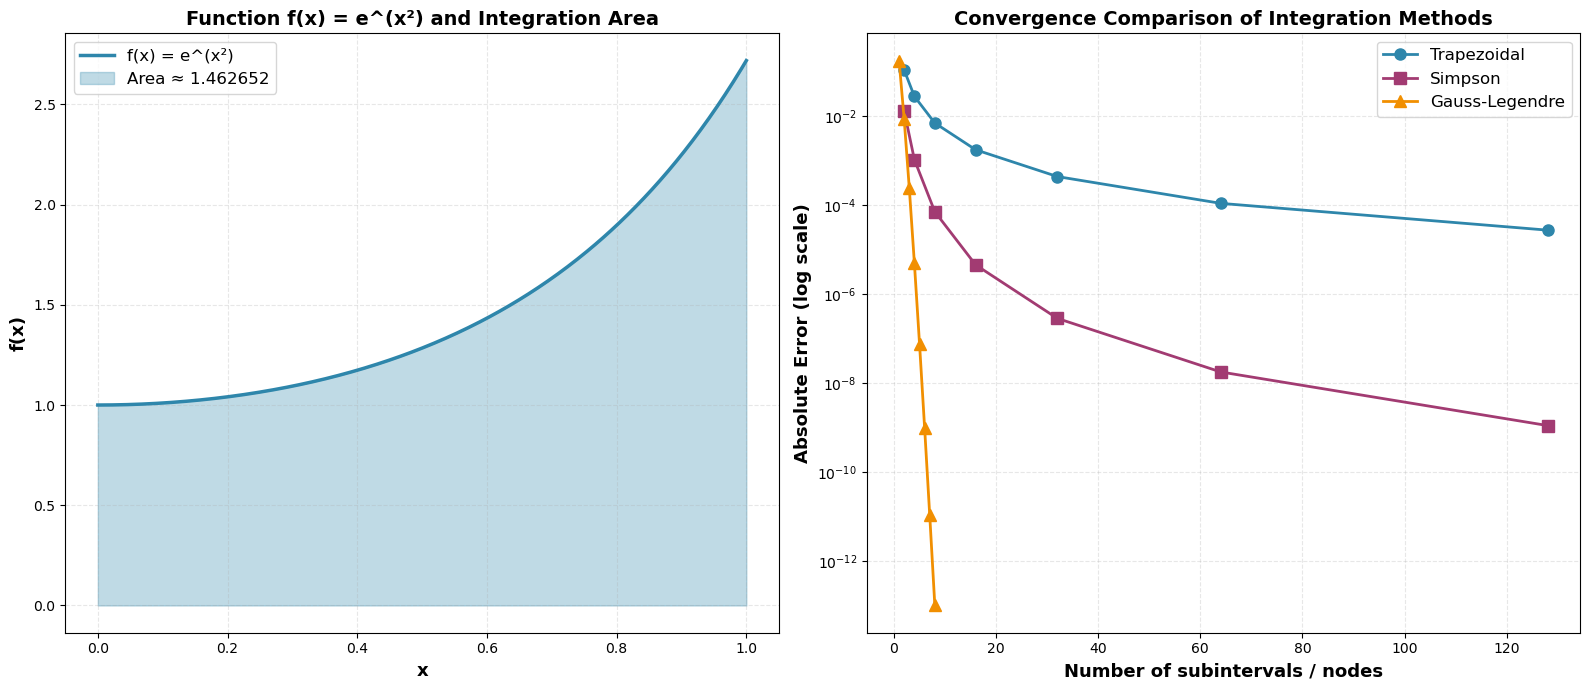

Results saved to: ../outputs/results/question3_results.txt

QUESTION 3 COMPLETED SUCCESFULLY


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
import sympy as sp

print("="*80)
print("QUESTION 3: Numerical Integration of f(x) = e^(x^2) on [0, 1]")
print("="*80)

# ================================================================
# Define the function
# ============================================
def f(x):
    return np.exp(x**2)

# Integration interval
a = 0.0
b = 1.0

print(f"\nFunction: f(x) = e^(x^2)")
print(f"Integration interval: [{a}, {b}]")

# ============================================================================
# Reference value (high-accuracy) for comparison
# ================================================================
# This integral has no elementary closed form, so we use a very accurate
# reference computed with scipy's adaptive quadrature.
reference_value, ref_error = integrate.quad(f, a, b)
print(f"\nReference value (scipy adaptive quad): {reference_value:.12f}")
print(f"Estimated reference error: {ref_error:.2e}")

# ============================================================================
# Part A.1: Composite Trapezoidal Rule
# ================================================
print("\n" + "="*80)
print("PART A.1: Composite Trapezoidal Rule")
print("="*80)

def trapezoidal_rule(func, a, b, n):
    """
    Composite Trapezoidal rule with n subintervals.
    Formula: h/2 * [f(x0) + 2*(f(x1)+...+f(x_{n-1})) + f(xn)]
    """
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = func(x)
    integral = (h / 2) * (y[0] + 2 * np.sum(y[1:-1]) + y[-1])
    return integral

# Compute trapezoidal results for several subinterval counts
n_values = [2, 4, 8, 16, 32, 64, 128]
print(f"\n{'n':>6} {'Trapezoidal':>18} {'Abs Error':>16}")
print("-" * 42)

trap_results = []
for n in n_values:
    result = trapezoidal_rule(f, a, b, n)
    error = abs(result - reference_value)
    trap_results.append(result)
    print(f"{n:>6} {result:>18.10f} {error:>16.2e}")

trap_final = trap_results[-1]

# ============================================================================
# Part A.2: Composite Simpson's Rule
# ============================================================
print("\n" + "="*80)
print("PART A.2: Composite Simpson's 1/3 Rule")
print("="*80)

def simpson_rule(func, a, b, n):
    """
    Composite Simpson's 1/3 rule with n subintervals (n must be even).
    Formula: h/3 * [f(x0) + 4*(od terms) + 2*(even terms) + f(xn)]
    """
    if n % 2 != 0:
        raise ValueError("n must be even for Simpson's rule")
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = func(x)
    integral = (h / 3) * (y[0] + 4 * np.sum(y[1:-1:2]) + 2 * np.sum(y[2:-1:2]) + y[-1])
    return integral

print(f"\n{'n':>6} {'Simpson':>18} {'Abs Error':>16}")
print("-" * 42)

simpson_results = []
for n in n_values:
    result = simpson_rule(f, a, b, n)
    error = abs(result - reference_value)
    simpson_results.append(result)
    print(f"{n:>6} {result:>18.10f} {error:>16.2e}")

simpson_final = simpson_results[-1]

# ============================================================
# Part B: Gaussian Quadrature
# ============================================================================
print("\n" + "="*80)
print("PART B: Gauss-Legendre Quadrature")
print("="*80)

def gauss_legendre(func, a, b, n):
    """
    Gauss-Legendre quadrature with n nodes.
    Nodes/weights are defined on [-1, 1], then mapped to [a, b].
    """
    # Get nodes and weights on [-1, 1]
    nodes, weights = np.polynomial.legendre.leggauss(n)
    # Linear transformation from [-1, 1] to [a, b]
    x_mapped = 0.5 * (b - a) * nodes + 0.5 * (b + a)
    integral = 0.5 * (b - a) * np.sum(weights * func(x_mapped))
    return integral

print(f"\n{'Points':>8} {'Gauss-Legendre':>18} {'Abs Error':>16}")
print("-" * 44)

gauss_n_values = [1, 2, 3, 4, 5, 6, 7, 8]
gauss_results = []
for n in gauss_n_values:
    result = gauss_legendre(f, a, b, n)
    error = abs(result - reference_value)
    gauss_results.append(result)
    print(f"{n:>8} {result:>18.10f} {error:>16.2e}")

gauss_final = gauss_results[-1]

# Print nodes and weights for a representative case (n = 3)
print("\nGauss-Legendre nodes and weights (n = 3, on [-1, 1]):")
nodes3, weights3 = np.polynomial.legendre.leggauss(3)
for i in range(3):
    print(f"  Node {i+1}: {nodes3[i]:>12.8f},  Weight {i+1}: {weights3[i]:>12.8f}")

# ================================================================
# Comparison Summary
# ============================================================================
print("\n" + "="*80)
print("COMPARISON OF METHODS (highest resolution)")
print("="*80)

print(f"\n{'Method':>30} {'Result':>18} {'Abs Error':>16}")
print("-" * 66)
print(f"{'Trapezoidal (n=128)':>30} {trap_final:>18.10f} {abs(trap_final-reference_value):>16.2e}")
print(f"{'Simpson (n=128)':>30} {simpson_final:>18.10f} {abs(simpson_final-reference_value):>16.2e}")
print(f"{'Gauss-Legendre (8 pts)':>30} {gauss_final:>18.10f} {abs(gauss_final-reference_value):>16.2e}")
print(f"{'Reference (scipy quad)':>30} {reference_value:>18.10f} {ref_error:>16.2e}")

# ================================================
# Visualization
# ============================================================
print("\n" + "="*80)
print("Creating Visualizations...")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# -- Left plot: the function and the area under the curve ---
x_fine = np.linspace(a, b, 400)
y_fine = f(x_fine)

axes[0].plot(x_fine, y_fine, color='#2E86AB', linewidth=2.5, label='f(x) = e^(x²)')
axes[0].fill_between(x_fine, y_fine, alpha=0.3, color='#2E86AB',
                     label=f'Area ≈ {reference_value:.6f}')
axes[0].set_xlabel('x', fontsize=13, fontweight='bold')
axes[0].set_ylabel('f(x)', fontsize=13, fontweight='bold')
axes[0].set_title('Function f(x) = e^(x²) and Integration Area',
                  fontsize=14, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3, linestyle='--')

# --- Right plot: convergence (error vs. evaluations, log scale) ---
trap_errors = [abs(r - reference_value) for r in trap_results]
simpson_errors = [abs(r - reference_value) for r in simpson_results]
gauss_errors = [abs(r - reference_value) for r in gauss_results]

axes[1].semilogy(n_values, trap_errors, marker='o', linewidth=2,
                 markersize=8, label='Trapezoidal', color='#2E86AB')
axes[1].semilogy(n_values, simpson_errors, marker='s', linewidth=2,
                 markersize=8, label='Simpson', color='#A23B72')
axes[1].semilogy(gauss_n_values, gauss_errors, marker='^', linewidth=2,
                 markersize=8, label='Gauss-Legendre', color='#F18F01')
axes[1].set_xlabel('Number of subintervals / nodes', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Absolute Error (log scale)', fontsize=13, fontweight='bold')
axes[1].set_title('Convergence Comparison of Integration Methods',
                  fontsize=14, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3, linestyle='--', which='both')

plt.tight_layout()
plt.savefig('../outputs/figures/question3_integration.png', dpi=300, bbox_inches='tight')
print("Figure saved to: ../outputs/figures/question3_integration.png")
plt.show()

# ============================================================
# Save results to text file
# ================================================
with open('../outputs/results/question3_results.txt', 'w') as out:
    out.write("="*80 + "\n")
    out.write("QUESTION 3: NUMERICAL INTEGRATION RESULTS\n")
    out.write("Function: f(x) = e^(x^2),  Interval: [0, 1]\n")
    out.write("="*80 + "\n\n")
    out.write(f"Reference value (scipy quad): {reference_value:.12f}\n\n")
    out.write(f"{'Method':>30} {'Result':>18} {'Abs Error':>16}\n")
    out.write("-"*66 + "\n")
    out.write(f"{'Trapezoidal (n=128)':>30} {trap_final:>18.10f} {abs(trap_final-reference_value):>16.2e}\n")
    out.write(f"{'Simpson (n=128)':>30} {simpson_final:>18.10f} {abs(simpson_final-reference_value):>16.2e}\n")
    out.write(f"{'Gauss-Legendre (8 pts)':>30} {gauss_final:>18.10f} {abs(gauss_final-reference_value):>16.2e}\n")

print("Results saved to: ../outputs/results/question3_results.txt")

print("\n" + "="*80)
print("QUESTION 3 COMPLETED SUCCESFULLY")
print("="*80)